In [20]:
import numpy as np
import os.path as op
import nibabel as nib
import neuropythy as ny

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from nilearn.surface import (
  PolyMesh, 
  PolyData, 
  SurfaceImage
)
from nilearn.plotting import (
  plot_surf_stat_map, 
  plot_surf_roi
)

In [21]:
import pandas as pd
from nilearn.maskers import SurfaceLabelsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn.plotting import plot_matrix

In [22]:
participant = "HCA6002236_V3_MR"
main_dir  = "/home/jovyan"
local_dir = op.join(main_dir, "hcp_data")
data_dir  = op.join(local_dir, participant, "MNINonLinear", "fsaverage_LR32k")
surf_dir  = data_dir

atlas_dir = op.join(main_dir, "shared", "data", "atlases")

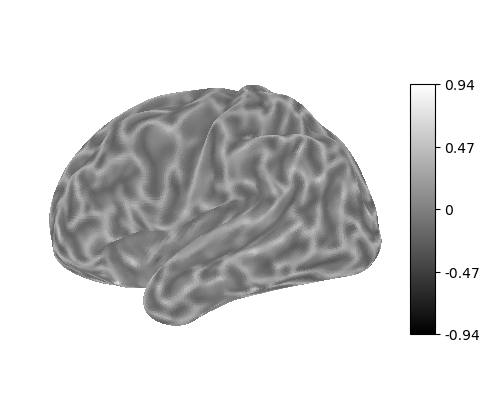

In [23]:
# load the surface mesh for the left and right hemispheres
filename = "{}.{}.inflated_MSMAll.32k_fs_LR.surf.gii"

mesh = PolyMesh(
  left  = op.join(data_dir, filename.format(participant, "L")), 
  right = op.join(data_dir, filename.format(participant, "R"))
)

# load the curvature data for the left and right hemispheres
filename  = f"{participant}.curvature_MSMAll.32k_fs_LR.dscalar.nii"
curv_data = ny.hcp.cifti_split(nib.load(op.join(surf_dir, filename)))
curv_data = PolyData(
  left  = np.nan_to_num(curv_data[0].flatten()),
  right = np.nan_to_num(curv_data[1].flatten())
)
curvature_image = SurfaceImage(mesh, curv_data)

plot_surf_stat_map(
  stat_map = curvature_image,
  hemi     = "left",    # options: "left", "right", "both"
  view     = "lateral",
  cmap     = "gray", 
)
plt.show()

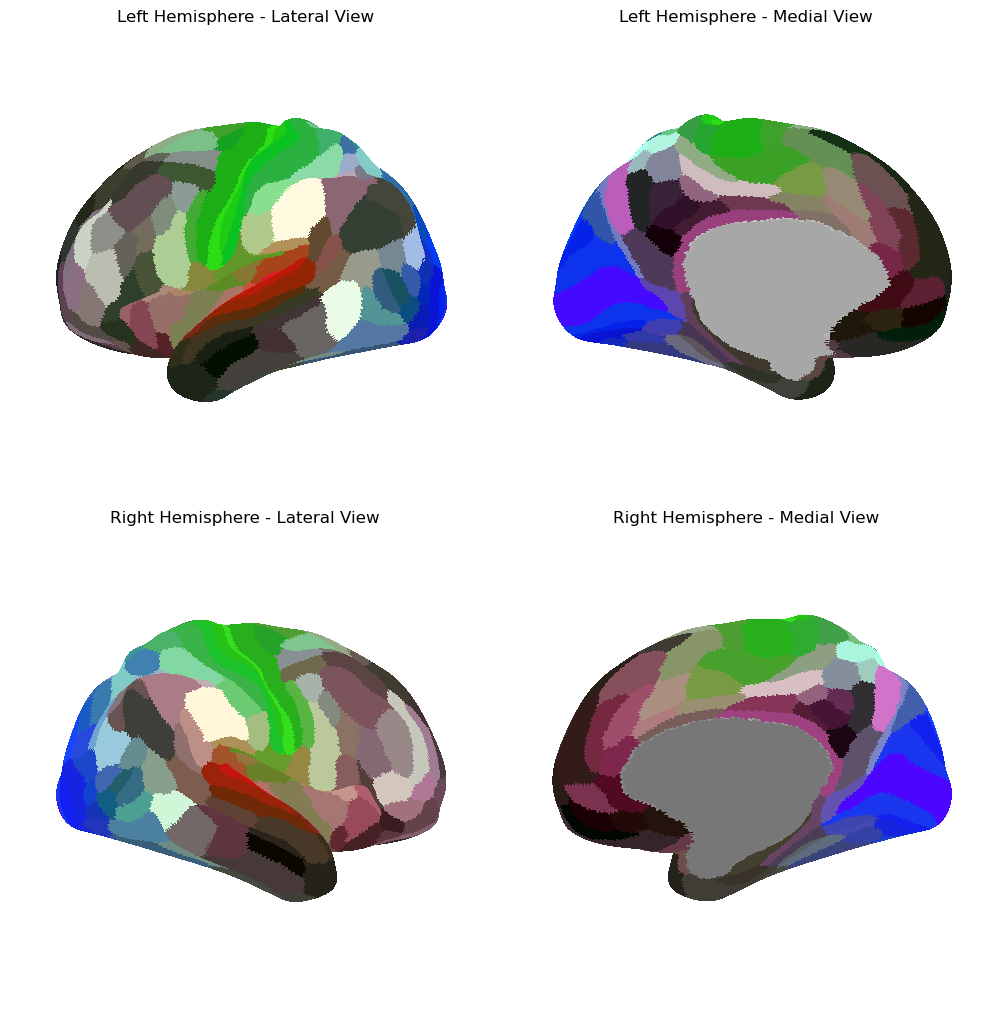

In [24]:
# load the glasser parcellations for the left and right hemispheres
filename  = "atl-MMPAll_space-fslr32k_hemi-{}_deterministic.label.gii"
glasser_parcels = PolyData(
  left  = op.join(atlas_dir, filename.format("L")),
  right = op.join(atlas_dir, filename.format("R"))
)
glasser_parcels = SurfaceImage(mesh, glasser_parcels)

# extract color table (ctable) from the glasser parcellation file
glasser_ctable = nib.load(op.join(atlas_dir, filename.format("L")))
glasser_ctable = glasser_ctable.labeltable.labels

glasser_cmap = np.zeros((len(glasser_ctable), 4)) # n_colors x RGBA
for label in glasser_ctable:
  glasser_cmap[label.key, :] = label.rgba
glasser_cmap = ListedColormap(glasser_cmap)

fig, axes = plt.subplots(2, 2, figsize = (10, 10), constrained_layout = True, 
  subplot_kw = { "projection": "3d" })
for i, hemi in enumerate(["left", "right"]):
  for j, view in enumerate(["lateral", "medial"]):
    # get the current axis for the subplot
    curr_ax = axes[i, j]

    # plot the surface mesh with glasser parcellation overlay
    plot_surf_roi(
      roi_map  = glasser_parcels,
      bg_map   = curvature_image,
      hemi     = hemi, 
      view     = view,
      cmap     = glasser_cmap,
      colorbar = False,
      vmin     = 0, 
      vmax     = len(glasser_ctable) - 1,
      title    = f"{hemi.capitalize()} Hemisphere - {view.capitalize()} View",
      axes     = curr_ax, 
      figure   = fig
    )
plt.show()

In [25]:
# path to the task fMRI CIFTI dtseries on the JupyterHub shared HCP-Aging mirror
# (read directly from there -- no need to stage/upload this one)
task     = "VISMOTOR"
pe_dir   = "PA"
run_name = f"tfMRI_{task}_{pe_dir}"
func_filename = f"{run_name}_Atlas_MSMAll_hp0_clean_rclean_tclean.dtseries.nii"
func_dir  = op.join(main_dir, "shared", "data", "HCP-Aging", participant, "MNINonLinear", "Results", run_name)
func_path = op.join(func_dir, func_filename)

print(func_path)
print("exists:", op.isfile(func_path))

/home/jovyan/shared/data/HCP-Aging/HCA6002236_V3_MR/MNINonLinear/Results/tfMRI_VISMOTOR_PA/tfMRI_VISMOTOR_PA_Atlas_MSMAll_hp0_clean_rclean_tclean.dtseries.nii
exists: True


In [26]:
# load the BOLD CIFTI and split grayordinates into per-hemisphere vertex data
bold_cifti = nib.load(func_path)
left_bold, right_bold = ny.hcp.cifti_split(bold_cifti)[:2]

# SurfaceLabelsMasker expects (n_vertices, n_timepoints) per hemisphere;
# cifti_split may return (n_timepoints, n_vertices) -- check against the mesh and transpose if needed
n_left_vertices = nib.load(
    op.join(data_dir, f"{participant}.L.inflated_MSMAll.32k_fs_LR.surf.gii")
).darrays[0].data.shape[0]

if left_bold.shape[0] != n_left_vertices and left_bold.shape[1] == n_left_vertices:
    left_bold, right_bold = left_bold.T, right_bold.T
elif left_bold.shape[0] != n_left_vertices:
    raise ValueError(f"Unexpected shape {left_bold.shape} for {n_left_vertices} left-hemisphere vertices")

print("left:", left_bold.shape, "right:", right_bold.shape)

func_img = SurfaceImage(mesh=mesh, data=PolyData(left=left_bold, right=right_bold))

left: (32492, 184) right: (32492, 184)


In [27]:
# build the region lookup table from the Glasser label table already loaded above
glasser_lut = pd.DataFrame({
    "index": [label.key for label in glasser_ctable],
    "name":  [label.label for label in glasser_ctable],
})

# average the vertex-level BOLD signal within each Glasser region
labels_masker = SurfaceLabelsMasker(
    labels_img  = glasser_parcels,   # already a SurfaceImage, built in the cell above
    lut         = glasser_lut,
    standardize = "zscore_sample",
    verbose     = 1,
).fit()

region_timeseries = labels_masker.transform(func_img)
print("region time series shape (timepoints, regions):", region_timeseries.shape)

[SurfaceLabelsMasker.fit] Loading regions from <SurfaceImage (64984,)>

[SurfaceLabelsMasker.fit] Finished fit

[SurfaceLabelsMasker.wrapped] Extracting region signals

[SurfaceLabelsMasker.wrapped] Cleaning extracted signals

region time series shape (timepoints, regions): (184, 360)


In [30]:
# compute the region x region correlation connectome
connectome_measure = ConnectivityMeasure(kind="correlation")
connectome = connectome_measure.fit_transform([region_timeseries])[0]

# region_names_ matches the transform() output columns exactly (background already excluded)
region_labels = list(labels_masker.region_names_.values())

import plotly.graph_objects as go

# show every 10th region name on the axes; hovering any cell reveals the full region pair regardless
tick_text = region_labels[::10]

fig = go.Figure(data=go.Heatmap(
    z = connectome,
    x = region_labels,
    y = region_labels,
    zmin = -1,
    zmax = 1,
    colorscale = "RdBu_r",
    colorbar = dict(title="correlation"),
    hovertemplate = "%{y} vs %{x}<br>r = %{z:.2f}<extra></extra>",
))
fig.update_xaxes(tickmode="array", tickvals=tick_text, ticktext=tick_text, tickangle=90)
fig.update_yaxes(tickmode="array", tickvals=tick_text, ticktext=tick_text)
fig.update_layout(
    title  = f"{participant} {run_name} functional connectome",
    width  = 900,
    height = 900,
)
fig.show()

/tmp/ipykernel_53745/815499611.py:3: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  connectome = connectome_measure.fit_transform([region_timeseries])[0]
